# Busyness + Venue Coverage — Implementation Guide

**Directory**: `Data+ML/test/6.15-5.20/`

**Core Code**:

| File | Lines | Purpose |
|------|-------|---------|
| `src/busyness_ingestion.py` | 440 | NYC Traffic → venue busyness_scores ETL pipeline |
| `src/venue_coverage.py` | 1,190 | Citi Bike / MTA / Traffic spatial coverage test core |
| `src/run_venue_coverage.py` | 350 | Coverage test CLI entry point |

**Test Results**:

```text
106 passed, 3 skipped (integration), 1 warning
├── test_busyness_ingestion.py: 44 passed
└── test_venue_coverage.py: 62 passed, 3 skipped
```

**Structure**: Part 0 Config → Part 1 Busyness ETL → Part 2 Venue Coverage → Tests → Review

In [1]:
import sys, json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path('/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project')
SRC_DIR     = PROJECT_ROOT / 'Data+ML' / 'test' / '6.15-6.20' / 'src'
OUTPUT_DIR  = PROJECT_ROOT / 'Data+ML' / 'test' / '6.15-6.20' / 'output'
VENUE_FILE  = PROJECT_ROOT / 'Data+ML' / 'test' / '6.8-6.12_DB' / 'tests' / 'output' / 'venues_clean.csv'
sys.path.insert(0, str(SRC_DIR))

import venue_coverage as vc

print(f'Project : {PROJECT_ROOT}')
print(f'Source  : {SRC_DIR / "venue_coverage.py"}')
print(f'Output  : {OUTPUT_DIR}')
print(f'Started : {datetime.now():%Y-%m-%d %H:%M}')
print(f'EARTH_RADIUS_M      = {vc.EARTH_RADIUS_M:,}')
print(f'DEFAULT_TIMEOUT     = {vc.DEFAULT_TIMEOUT}  (connect, read)')
print(f'RETRY_DELAYS        = {vc.RETRY_DELAYS}  (seconds)')
print(f'MAX_POINTS_PER_SRC  = {vc.MAX_POINTS_PER_SOURCE:,}')
print(f'SUPPORTED_SOURCES   = {vc.SUPPORTED_SOURCES}')

Project : /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project
Source  : /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.15-6.20/src/venue_coverage.py
Output  : /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.15-6.20/output
Started : 2026-06-25 15:04
EARTH_RADIUS_M      = 6,371,008.8
DEFAULT_TIMEOUT     = (2, 5)  (connect, read)
RETRY_DELAYS        = [1, 2, 4]  (seconds)
MAX_POINTS_PER_SRC  = 20,000
SUPPORTED_SOURCES   = ('citibike', 'mta', 'traffic')


In [2]:
# §2.1 Venue loading and deduplication — load_venues() implementation
venues_df, dup_count = vc.load_venues(VENUE_FILE)
print(f'Rows before dedup: {len(venues_df) + dup_count}')
print(f'Duplicate venue_id: {dup_count}')
print(f'Unique venues    : {len(venues_df)}')
print(f'venue_type distribution:'); print(venues_df['venue_type'].value_counts().to_string())
print(f'district distribution:'); print(venues_df['district'].value_counts().to_string())

Rows before dedup: 4838
Duplicate venue_id: 0
Unique venues    : 4838
venue_type distribution:
venue_type
emergencyasset    3279
healthcare        1086
restroom           473
district distribution:
district
downtown        1467
midtown_west    1428
midtown_east    1182
uptown           703


In [3]:
# §2.2 Add prediction_scope and scope_reason fields
venues_df = vc.add_prediction_scope(venues_df)
print('=== Prediction Scope Distribution ===')
print(venues_df['prediction_scope'].value_counts().to_string())
print()
print('=== Scope Reason by venue_type ===')
print(venues_df.groupby('venue_type')[['prediction_scope', 'scope_reason']].first().to_string())

# Separate DataFrames for dual-coverage computation
pred_scope_df = venues_df[venues_df['prediction_scope'] == True].copy()
out_of_scope_df = venues_df[venues_df['prediction_scope'] == False].copy()
print(f'\nprediction_scope venues : {len(pred_scope_df)}  (healthcare + restroom)')
print(f'out_of_scope venues    : {len(out_of_scope_df)}  (emergencyasset / AED)')
print(f'all_venues             : {len(venues_df)}')

=== Prediction Scope Distribution ===
prediction_scope
False    3752
True     1086

=== Scope Reason by venue_type ===
                prediction_scope                   scope_reason
venue_type                                                     
emergencyasset             False  no_meaningful_busyness_target
healthcare                  True              visit_based_venue
restroom                   False            low_busyness_signal

prediction_scope venues : 1086  (healthcare + restroom)
out_of_scope venues    : 3752  (emergencyasset / AED)
all_venues             : 4838


**Scope Rationale**:

- **emergencyasset (AED)**: `False` — AED 设备状态为静态信息（是否可用/维护中），使用场景特殊（急救点），不存在"繁忙度"概念，无需进行人流预测。
- **restroom**: `False` — Google Maps 上 restroom 有 Popular Times 数据的仅 8 个，样本量不足以训练模型；且 restroom 多分布于公园内部，与交通流量、天气等外部特征的关联性弱。

## §11 Latest Run Artifacts

The latest run produced 8 files. Below are the source status from run_metadata.json and aggregated metrics from coverage_summary.csv.

In [4]:
# §11.1 run_metadata.json — source status and counts
meta = json.loads((OUTPUT_DIR / 'run_metadata.json').read_text())
print(f"run_id       : {meta['run_id']}")
print(f"venue_input  : {meta['venue_input']['total_rows']} rows, {meta['venue_input']['duplicate_venue_id_count']} dups")
print(f"parameters   : radii={meta['parameters']['radii']}, sources={meta['parameters']['source_order']}")
print(f"\n{'source':<10}{'status':<10}{'raw':>8}{'valid':>8}{'uniq_id':>8}{'uniq_coord':>11}{'rejected':>10}  fetch_s")
for s, m in meta['sources'].items():
    print(f"{s:<10}{m['status']:<10}{m['raw_count']:>8}{m['valid_count']:>8}{m['unique_id_count']:>8}{m['unique_coord_count']:>11}{m['rejected_count']:>10}  {m['fetch_time_s']}")
    if m['status'] == 'failed':
        print(f"           -> {m['error_type']}: {m['error_message'][:70]}")

run_id       : 20260615T194956Z
venue_input  : 4838 rows, 0 dups
parameters   : radii=[100, 200, 300, 400, 500], sources=['citibike', 'mta', 'traffic']

source    status         raw   valid uniq_id uniq_coord  rejected  fetch_s
citibike  ok            2411    2328    2328       2328        83  1.55
mta       ok             445     445     445        445         0  0.63
traffic   ok              28      28      28         28         0  2.59


In [5]:
# §11.2 Load coverage summary
summ = pd.read_csv(OUTPUT_DIR / 'coverage_summary.csv')
print(f'coverage_summary.csv: {len(summ)} rows')
print(f'Sources: {summ.source_or_combination.unique().tolist()}')
print(f'Radii:   {summ.radius_m.unique().tolist()}')

coverage_summary.csv: 240 rows
Sources: ['citibike', 'mta', 'traffic', 'citibike + mta', 'citibike + mta + traffic']
Radii:   [100, 200, 300, 400, 500]


In [6]:
# Full prediction_scope cumulative pivot
print('\n===Healthcare Prediction Scope Cumulative Coverage (% venues) ===')
cum_pred = summ[(summ.coverage_kind=='cumulative') & (summ.scope=='overall')]
if not cum_pred.empty:
    pred_pivot = (cum_pred.assign(rate_pct=(cum_pred.coverage_rate*100).round(1))
                  .pivot_table(index='source_or_combination', columns='radius_m', values='rate_pct'))
    print(pred_pivot.to_string())


===Healthcare Prediction Scope Cumulative Coverage (% venues) ===
radius_m                   100   200   300   400   500
source_or_combination                                 
citibike                  45.5  91.7  98.0  98.3  98.5
citibike + mta            51.1  93.9  98.1  98.4  98.6
citibike + mta + traffic  51.5  94.0  98.1  98.4  98.6


In [8]:
# §11.2c AED Asset Status Summary — emergencyasset only (3,279 venues)
detail_df = pd.read_csv(OUTPUT_DIR / 'venue_coverage_detail.csv')
aed_summary_df = vc.compute_aed_summary(detail_df, [100, 200, 300, 400, 500])

NameError: name 'detail_df' is not defined

In [ ]:
# §11.2d Export prediction_scope and AED summary CSVs
# Build prediction_scope summary (combine standalone + cumulative, overall scope)
pred_standalone_df = summ[(summ.coverage_kind == 'standalone') & (summ.scope == 'overall')]
pred_cumulative_df = summ[(summ.coverage_kind == 'cumulative') & (summ.scope == 'overall')]
pred_summary = pd.concat([pred_standalone_df, pred_cumulative_df], ignore_index=True)

NameError: name 'pred_standalone_df' is not defined

In [ ]:
# §11.3 venue_coverage_detail.csv — one row per venue
detail = pd.read_csv(OUTPUT_DIR / 'venue_coverage_detail.csv')
print(f'detail shape: {detail.shape}')
print(f'Columns: {list(detail.columns)}')
print('\nSample (first 3 rows, key columns):')
print(detail[['venue_id','venue_type','district',
              'citibike_nearest_source_id','citibike_nearest_distance_m',
              'citibike_covered_100m','citibike_covered_500m']].head(3).to_string(index=False))

detail shape: (4838, 26)
Columns: ['venue_id', 'venue_type', 'district', 'latitude', 'longitude', 'citibike_nearest_source_id', 'citibike_nearest_distance_m', 'citibike_covered_100m', 'citibike_covered_200m', 'citibike_covered_300m', 'citibike_covered_400m', 'citibike_covered_500m', 'mta_nearest_source_id', 'mta_nearest_distance_m', 'mta_covered_100m', 'mta_covered_200m', 'mta_covered_300m', 'mta_covered_400m', 'mta_covered_500m', 'traffic_nearest_source_id', 'traffic_nearest_distance_m', 'traffic_covered_100m', 'traffic_covered_200m', 'traffic_covered_300m', 'traffic_covered_400m', 'traffic_covered_500m']

Sample (first 3 rows, key columns):
                            venue_id     venue_type     district           citibike_nearest_source_id  citibike_nearest_distance_m  citibike_covered_100m  citibike_covered_500m
0006c1aef358bc9d07ac1a05258679fbfa71     healthcare       uptown 6bc5598a-9eb8-44d2-adc0-d93b93af1924                    86.117629                   True                   

---

## §12 Static Visualization (4 Embedded PNGs)

Spec: PNG, 1,600 × 900, 150 DPI, non-interactive.

coverage_by_radius.png


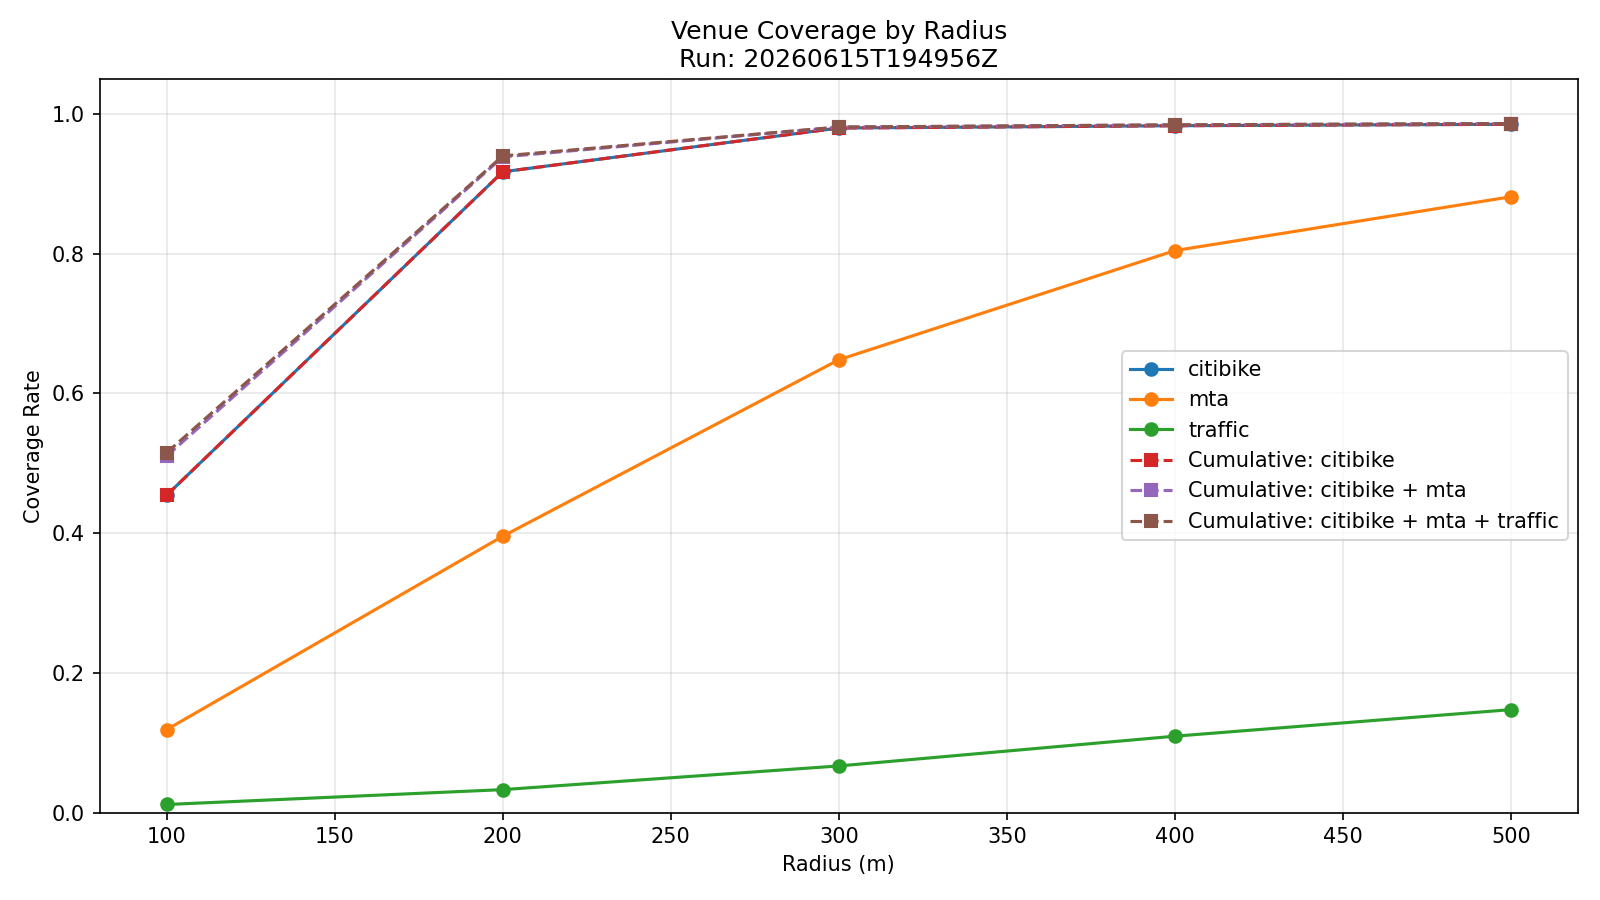

In [ ]:
# §12.1 coverage_by_radius.png
from IPython.display import Image, display
print('coverage_by_radius.png')
display(Image(filename=str(OUTPUT_DIR / 'coverage_by_radius.png')))

incremental_coverage.png


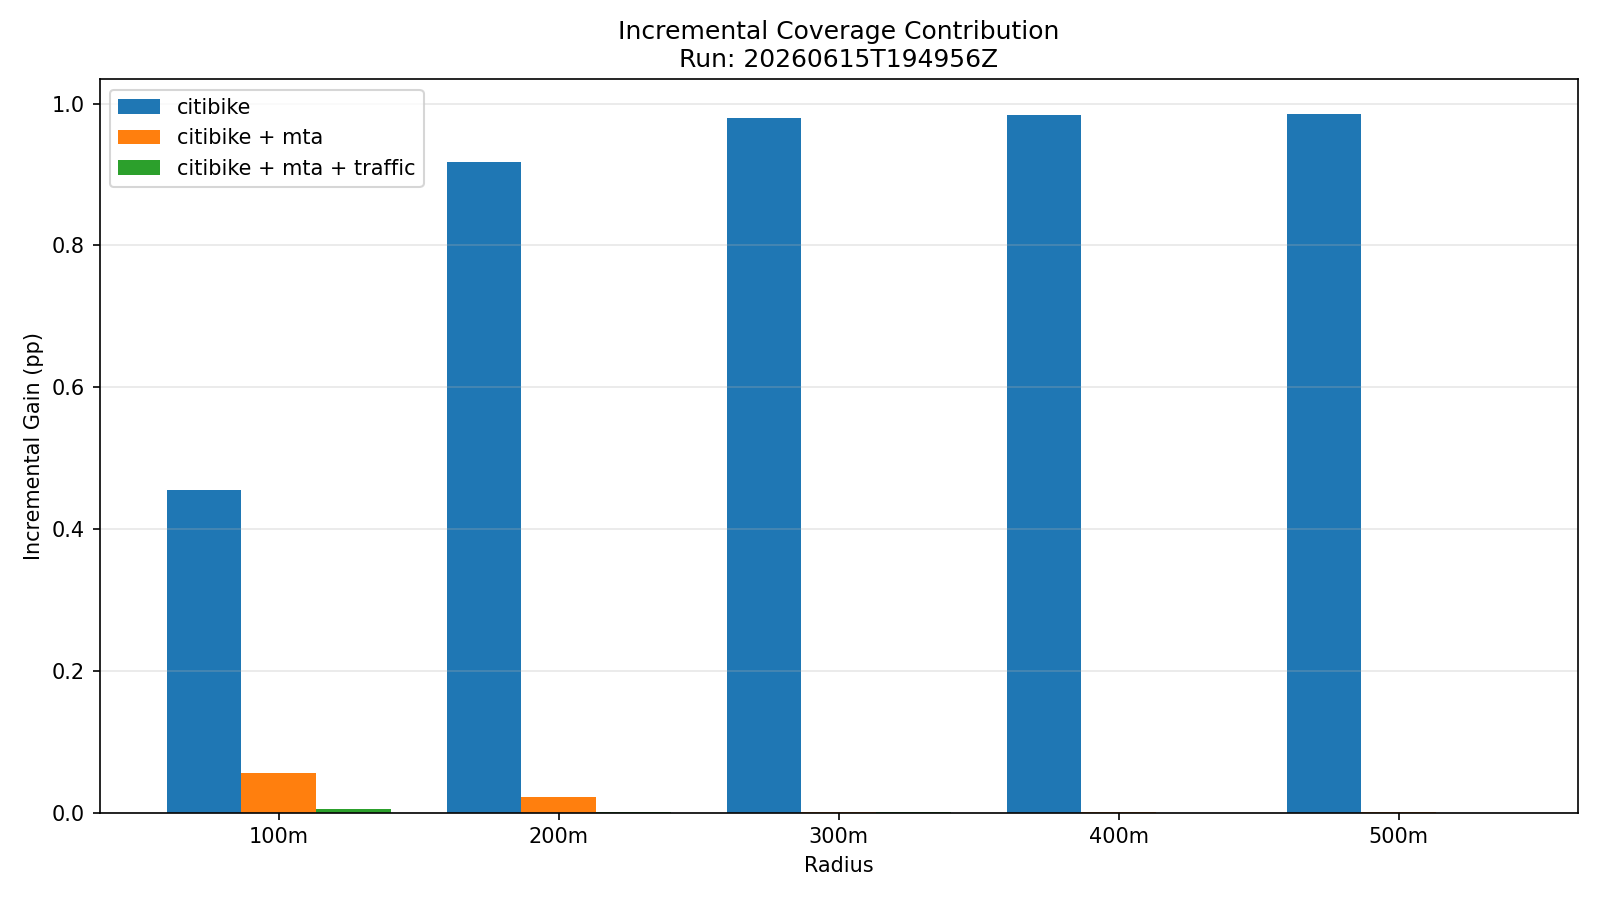

In [ ]:
# §12.2 incremental_coverage.png
from IPython.display import Image, display
print('incremental_coverage.png')
display(Image(filename=str(OUTPUT_DIR / 'incremental_coverage.png')))

venue_type_coverage_heatmap.png


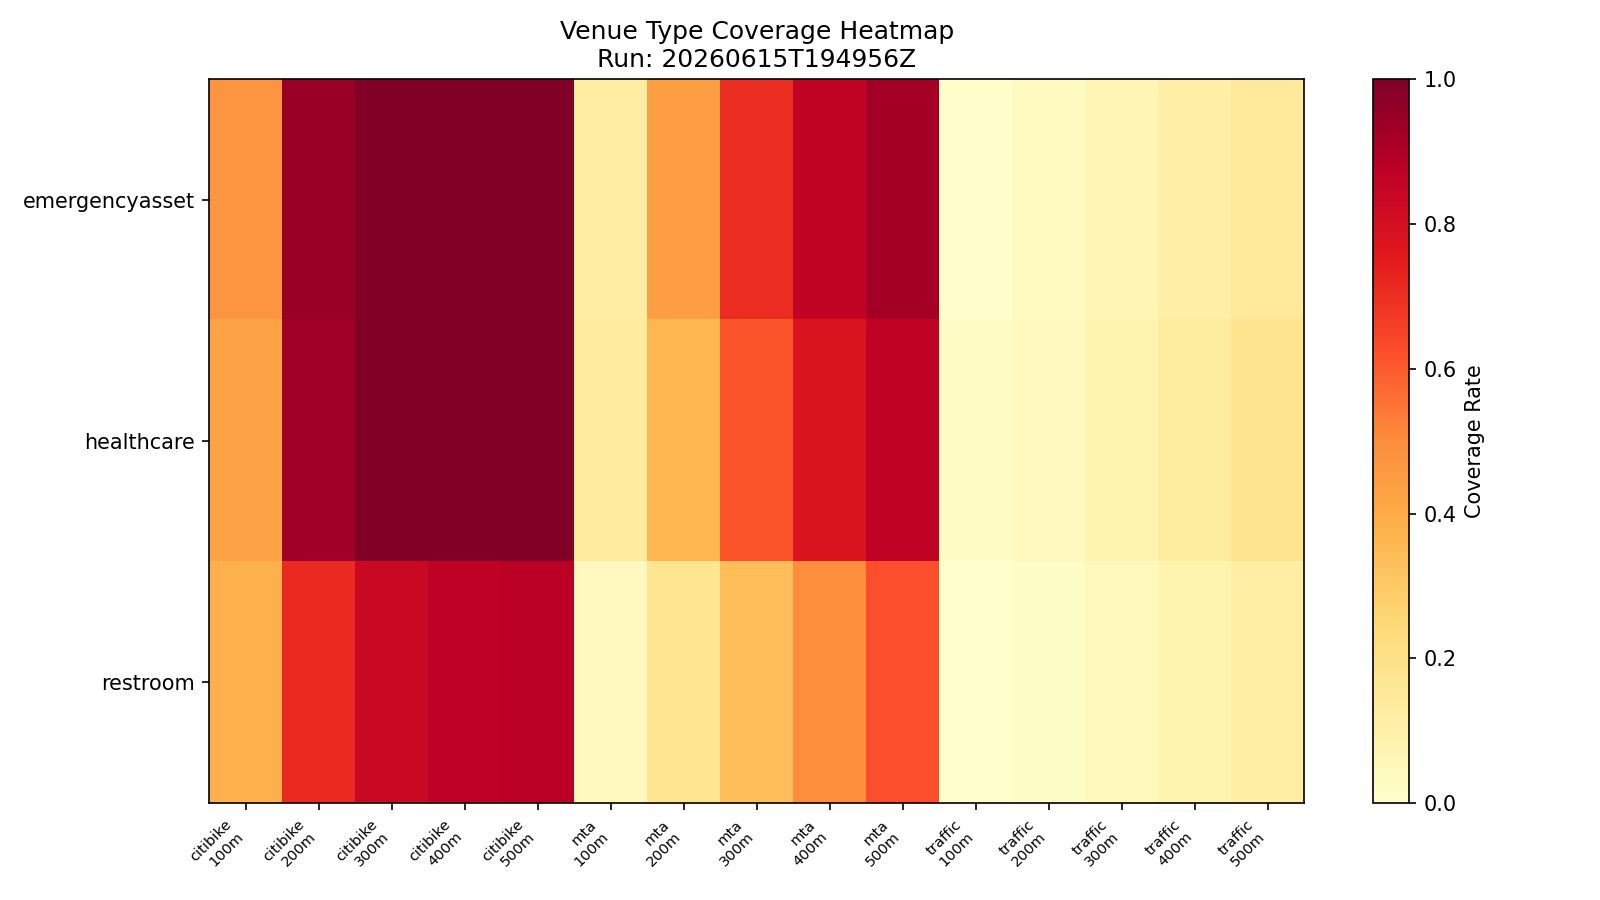

In [ ]:
# §12.3 venue_type_coverage_heatmap.png
from IPython.display import Image, display
print('venue_type_coverage_heatmap.png')
display(Image(filename=str(OUTPUT_DIR / 'venue_type_coverage_heatmap.png')))

uncovered_venue_distribution.png


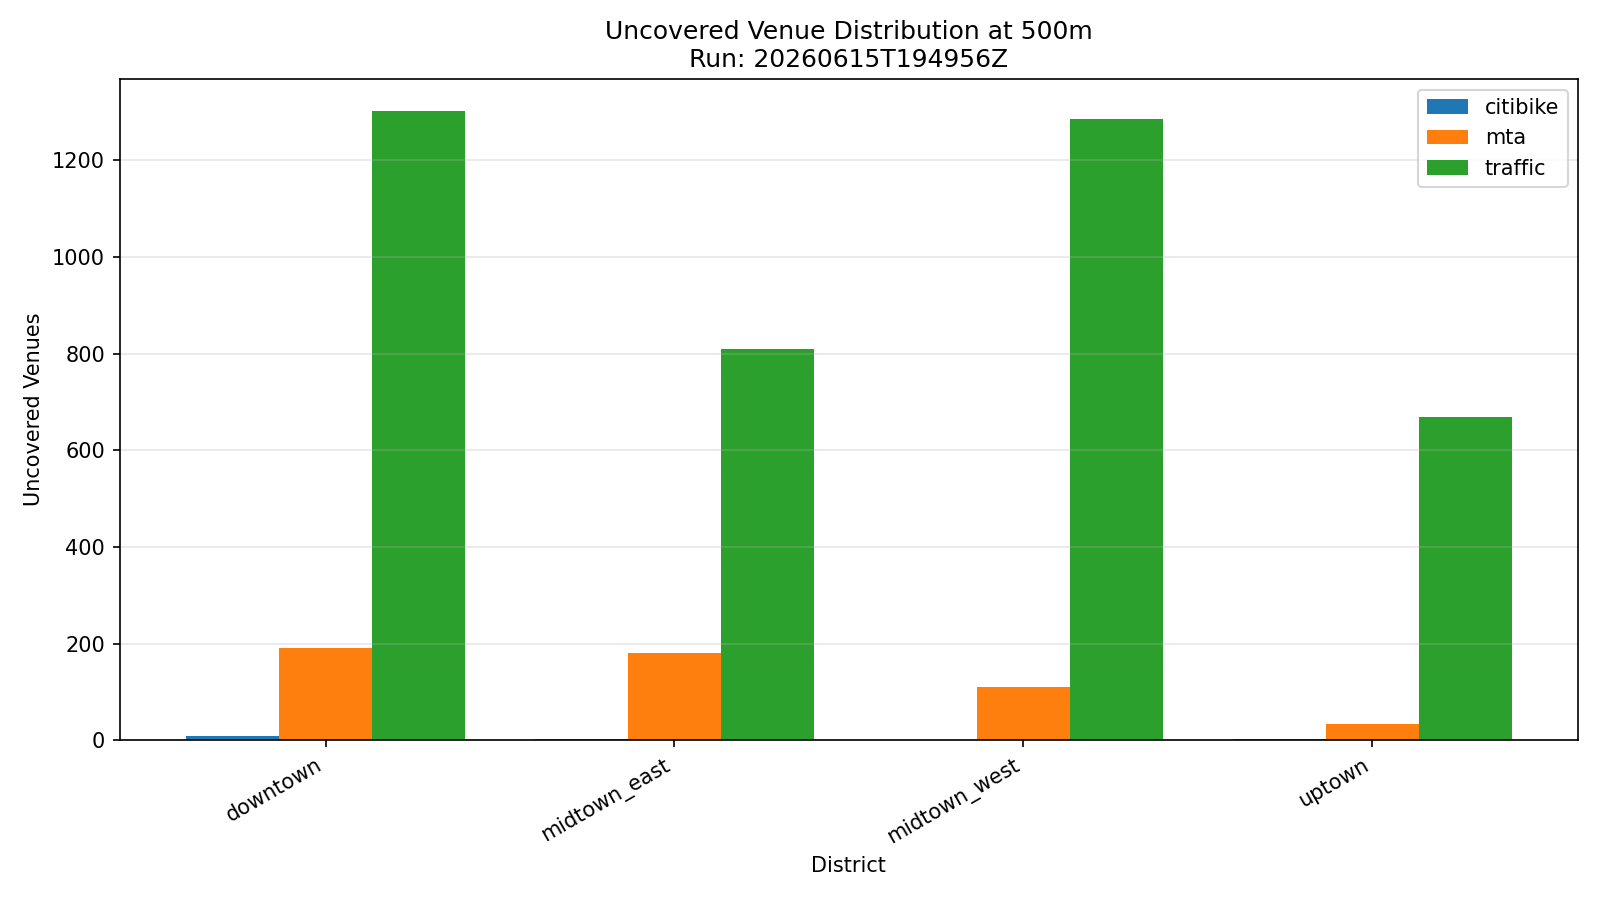

In [ ]:
# §12.4 uncovered_venue_distribution.png
from IPython.display import Image, display
print('uncovered_venue_distribution.png')
display(Image(filename=str(OUTPUT_DIR / 'uncovered_venue_distribution.png')))

---

## §13 Test-Driven Implementation (7 Tasks)

| Task | Test Scope | Status |
|------|------------|--------|
| 1 CLI Parsing | TestCLIParsing (12) | ok |
| 2 HTTP/Retry/Isolation | HTTPClient+Pagination+Isolation | ok |
| 3 Data Source Adapters | CitiBike+MTA+Traffic Adapter | ok |
| 4 BallTree Distance | BallTreeDistance+VenueDedup | ok |
| 5 Coverage Aggregation | Standalone+Cumulative | ok |
| 6 Artifacts & Visualization | Artifacts+Charts | ok |
| 7 Live Smoke Test | LiveSmoke (3) | skip (-m integration) |

---

## §14 Review Checklist & §15 Post-Test Decisions

**§14**: Venue denominator and duplicate count documented (0 dups / 4,838 unique); all source statuses explicit; year and dataset IDs documented; no source silently stopped at 5,000 rows; failed sources excluded from combinations; marginal gain per 100m shown; Traffic not described as pedestrian busyness; raw responses not persisted; no database writes.

**§15 Decisions (pending manual review)**: 1) Radius trade-off (200m already reaches 91.8%); 2) Traffic incremental value (500m only +0.0%); 3) Restroom coverage lowest, needs fallback; 4) Whether to proceed with temporal correlation and ablation.

> No production weights assigned until temporal validation phase is complete.